# Fresh-Check Training v8.1 — MQ3 Sensor

## What's Different from v8.0

- **MQ3 sensor instead of MQ2.** MQ3 detects ethanol specifically (which is what bananas emit), giving much higher PPM ranges.
- **Updated `STAGE_THRESHOLDS`** to match MQ3's range (~80 to ~30,000 PPM).
- **Bug fix:** `classification_report` now uses `labels=` parameter to handle cases where some stages might be missing from the test set.

Everything else (chained model architecture, cascading one-hot encoding, stratified split) is identical to v8.0.

## 0. Setup

In [29]:
import pandas as pd
import numpy as np
from scipy import stats
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
import joblib
import os
import json

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('Setup complete')

Setup complete


## 1. Configuration — UPDATED for MQ3

In [30]:
CSV_FILE = 'banana_mq3_synthetic.csv'   # MQ3 dataset
OUTPUT_DIR = './models_v8'
SENSOR = 'S0'

WINDOW_SIZE = 36       # 6 hours of history at 10-min intervals
RECENT_WINDOW = 6      # 1 hour for recent trend

# ───────────────────────────────────────────────────────
# MQ3 STAGE THRESHOLDS (vs old MQ2 values 500/2000/5000)
# Calibrated for ethanol-specific MQ3 sensor:
#   Fresh:    < 1,500 PPM
#   Ripe:     1,500 - 8,000 PPM
#   Overripe: 8,000 - 18,000 PPM
#   Spoiled:  > 18,000 PPM
# ───────────────────────────────────────────────────────
# STAGE_THRESHOLDS = {
#     'fresh':    1500,
#     'ripe':     8000,
#     'overripe': 18000,
# }

STAGE_THRESHOLDS = {
    'fresh':    10000,   # < 10k = fresh
    'ripe':     15000,   # 10k-15k = ripe
    'overripe': 22000,   # 15k-22k = overripe
                         # > 22k = spoiled
}

STAGE_ORDER = ['fresh', 'ripe', 'overripe', 'spoiled']

CV_NOISE_AGREE = 0.85
CV_NOISE_OFF1  = 0.10
CV_NOISE_OFF2  = 0.05

STAGE_TO_ACTION = {
    'fresh':    'maintain_display',
    'ripe':     'promote_for_sale',
    'overripe': 'apply_discount',
    'spoiled':  'remove_from_shelf'
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Configuration loaded for MQ3')
print(f'Output: {OUTPUT_DIR}')
print(f'Thresholds: {STAGE_THRESHOLDS}')

Configuration loaded for MQ3
Output: ./models_v8
Thresholds: {'fresh': 10000, 'ripe': 15000, 'overripe': 22000}


## 2. Load Data

Loaded 10080 readings
Date range: 2026-04-14 00:00:00 to 2026-04-20 23:59:00
PPM range: 153 to 31421


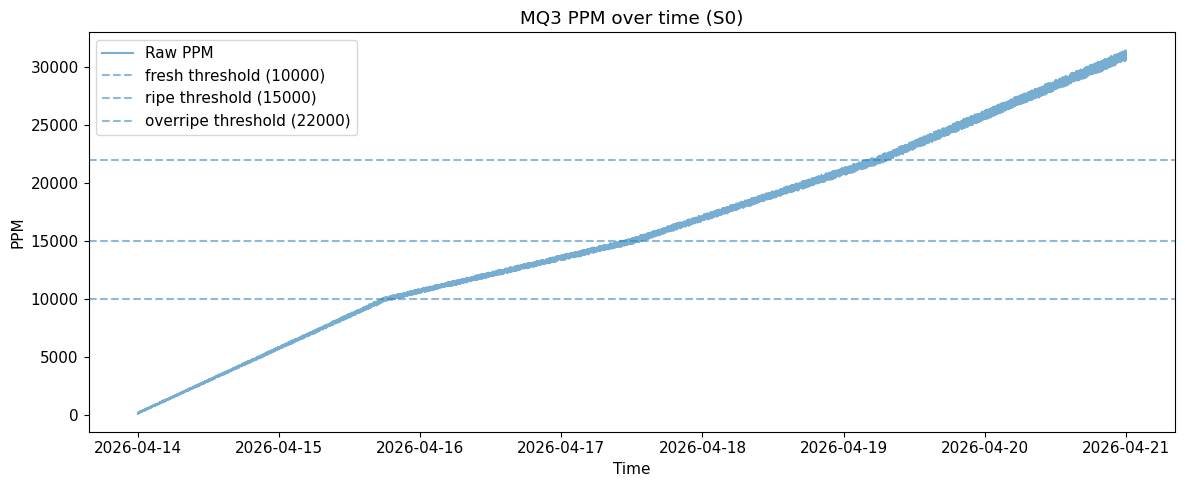

In [31]:
df = pd.read_csv(CSV_FILE)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print(f'Loaded {len(df)} readings')
print(f'Date range: {df["Timestamp"].min()} to {df["Timestamp"].max()}')
print(f'PPM range: {df[f"{SENSOR}_PPM"].min():.0f} to {df[f"{SENSOR}_PPM"].max():.0f}')

# Plot the curve so you can verify thresholds visually
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['Timestamp'], df[f'{SENSOR}_PPM'], alpha=0.6, label='Raw PPM')
for stage, thresh in STAGE_THRESHOLDS.items():
    ax.axhline(y=thresh, linestyle='--', alpha=0.5, label=f'{stage} threshold ({thresh})')
ax.set_xlabel('Time')
ax.set_ylabel('PPM')
ax.set_title(f'MQ3 PPM over time ({SENSOR})')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Feature Engineering (same as v8)

In [32]:
def engineer_features(df, sensor_prefix, start_time):
    v_col = f'{sensor_prefix}_V'
    ppm_col = f'{sensor_prefix}_PPM'

    features_list = []

    for i in range(WINDOW_SIZE, len(df)):
        window = df.iloc[i-WINDOW_SIZE:i]
        recent = df.iloc[i-RECENT_WINDOW:i]
        current = df.iloc[i]

        hours_elapsed = (current['Timestamp'] - start_time).total_seconds() / 3600

        ppm_values = window[ppm_col].values
        ppm_mean = np.mean(ppm_values)
        ppm_std = np.std(ppm_values)
        ppm_median = np.median(ppm_values)
        ppm_min = np.min(ppm_values)
        ppm_max = np.max(ppm_values)
        ppm_range = ppm_max - ppm_min
        ppm_current = current[ppm_col]
        ppm_cv = ppm_std / ppm_mean if ppm_mean > 0 else 0

        x_hours = np.arange(len(ppm_values)) * (10/60)
        slope_result = stats.linregress(x_hours, ppm_values)
        ppm_slope = slope_result.slope
        ppm_r_squared = slope_result.rvalue**2

        recent_ppm = recent[ppm_col].values
        recent_slope = 0
        if len(recent_ppm) >= 3:
            x_recent = np.arange(len(recent_ppm)) * (10/60)
            recent_slope = stats.linregress(x_recent, recent_ppm).slope

        ppm_acceleration = recent_slope - ppm_slope

        v_values = window[v_col].values
        v_mean = np.mean(v_values)
        v_std = np.std(v_values)
        v_current = current[v_col]
        v_slope = stats.linregress(x_hours, v_values).slope

        ppm_q25 = np.percentile(ppm_values, 25)
        ppm_q75 = np.percentile(ppm_values, 75)
        ppm_iqr = ppm_q75 - ppm_q25

        features_list.append({
            'timestamp': current['Timestamp'],
            'hours_elapsed': hours_elapsed,
            'ppm_current': ppm_current,
            'ppm_mean': ppm_mean,
            'ppm_median': ppm_median,
            'ppm_std': ppm_std,
            'ppm_min': ppm_min,
            'ppm_max': ppm_max,
            'ppm_range': ppm_range,
            'ppm_cv': ppm_cv,
            'ppm_slope': ppm_slope,
            'ppm_r_squared': ppm_r_squared,
            'ppm_q25': ppm_q25,
            'ppm_q75': ppm_q75,
            'ppm_iqr': ppm_iqr,
            'recent_slope': recent_slope,
            'ppm_acceleration': ppm_acceleration,
            'v_mean': v_mean,
            'v_std': v_std,
            'v_current': v_current,
            'v_slope': v_slope,
        })

    return pd.DataFrame(features_list)

start_time = df['Timestamp'].min()
features_df = engineer_features(df, SENSOR, start_time)
print(f'Generated {len(features_df)} feature samples')

Generated 10044 feature samples


## 4. Generate Labels (using MQ3 thresholds)

In [33]:
def assign_stage(ppm_mean):
    if ppm_mean < STAGE_THRESHOLDS['fresh']:
        return 'fresh'
    elif ppm_mean < STAGE_THRESHOLDS['ripe']:
        return 'ripe'
    elif ppm_mean < STAGE_THRESHOLDS['overripe']:
        return 'overripe'
    else:
        return 'spoiled'

features_df['true_stage'] = features_df['ppm_mean'].apply(assign_stage)

print('True label distribution:')
for stage in STAGE_ORDER:
    count = (features_df['true_stage'] == stage).sum()
    pct = count / len(features_df) * 100
    print(f'  {stage:10s}: {count:4d} samples ({pct:.1f}%)')

# Warn if any class is missing
missing = [s for s in STAGE_ORDER if (features_df['true_stage'] == s).sum() == 0]
if missing:
    print(f'\nWARNING: classes {missing} have zero samples — adjust STAGE_THRESHOLDS')

True label distribution:
  fresh     : 2499 samples (24.9%)
  ripe      : 2519 samples (25.1%)
  overripe  : 2533 samples (25.2%)
  spoiled   : 2493 samples (24.8%)


## 5. Generate Synthetic CV Labels

In [34]:
def generate_synthetic_cv_label(true_stage, rng):
    true_idx = STAGE_ORDER.index(true_stage)
    roll = rng.random()

    if roll < CV_NOISE_AGREE:
        return true_stage
    elif roll < CV_NOISE_AGREE + CV_NOISE_OFF1:
        offset = rng.choice([-1, 1])
        cv_idx = max(0, min(len(STAGE_ORDER) - 1, true_idx + offset))
        return STAGE_ORDER[cv_idx]
    else:
        offset = rng.choice([-2, 2])
        cv_idx = max(0, min(len(STAGE_ORDER) - 1, true_idx + offset))
        return STAGE_ORDER[cv_idx]

rng = np.random.default_rng(seed=42)
features_df['cv_stage'] = features_df['true_stage'].apply(
    lambda s: generate_synthetic_cv_label(s, rng)
)

agreement = (features_df['cv_stage'] == features_df['true_stage']).mean()
print(f'CV-True agreement rate: {agreement:.1%}')

CV-True agreement rate: 89.1%


## 6. Cascading One-Hot Encoding

In [35]:
def cascading_one_hot(stage):
    idx = STAGE_ORDER.index(stage)
    return [1 if idx >= 1 else 0, 1 if idx >= 2 else 0, 1 if idx >= 3 else 0]

encoded = features_df['cv_stage'].apply(cascading_one_hot)
features_df['cv_at_least_ripe'] = encoded.apply(lambda x: x[0])
features_df['cv_at_least_overripe'] = encoded.apply(lambda x: x[1])
features_df['cv_at_least_spoiled'] = encoded.apply(lambda x: x[2])

print('Cascading encoding sample:')
print(features_df[['cv_stage', 'cv_at_least_ripe', 'cv_at_least_overripe', 'cv_at_least_spoiled']].head(8))

Cascading encoding sample:
   cv_stage  cv_at_least_ripe  cv_at_least_overripe  cv_at_least_spoiled
0     fresh                 0                     0                    0
1     fresh                 0                     0                    0
2     fresh                 0                     0                    0
3     fresh                 0                     0                    0
4  overripe                 1                     1                    0
5     fresh                 0                     0                    0
6     fresh                 0                     0                    0
7     fresh                 0                     0                    0


## 7. Prepare Feature Matrix

In [36]:
EXCLUDE_COLS = [
    'timestamp', 'true_stage', 'cv_stage',
    'ppm_mean', 'ppm_median',
    'cv_at_least_ripe', 'cv_at_least_overripe', 'cv_at_least_spoiled',
]

gas_only_cols = [c for c in features_df.columns if c not in EXCLUDE_COLS]
chained_cols = gas_only_cols + ['cv_at_least_ripe', 'cv_at_least_overripe', 'cv_at_least_spoiled']

print(f'Gas-only features: {len(gas_only_cols)}')
print(f'Chained features:  {len(chained_cols)}')

X_gas_only = features_df[gas_only_cols].values
X_chained = features_df[chained_cols].values
y = features_df['true_stage'].values

label_encoder = LabelEncoder()
label_encoder.fit(STAGE_ORDER)
y_encoded = label_encoder.transform(y)

print(f'\nClasses present: {list(np.unique(y))}')

Gas-only features: 18
Chained features:  21

Classes present: ['fresh', 'overripe', 'ripe', 'spoiled']


## 8. Stratified 80/20 Split

In [37]:
indices = np.arange(len(y_encoded))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, stratify=y_encoded, random_state=42
)

X_gas_train = X_gas_only[train_idx]
X_gas_test = X_gas_only[test_idx]
X_chained_train = X_chained[train_idx]
X_chained_test = X_chained[test_idx]
y_train = y_encoded[train_idx]
y_test = y_encoded[test_idx]

print(f'Train: {len(train_idx)} | Test: {len(test_idx)}')

Train: 8035 | Test: 2009


## 9. Train Models

In [38]:
BEST_DEPTH = 4

gas_only_model = DecisionTreeClassifier(max_depth=BEST_DEPTH, min_samples_leaf=5, random_state=42)
gas_only_model.fit(X_gas_train, y_train)

chained_model = DecisionTreeClassifier(max_depth=BEST_DEPTH, min_samples_leaf=5, random_state=42)
chained_model.fit(X_chained_train, y_train)

print('Both models trained.')

Both models trained.


## 10. Evaluate (with bug fix)

In [40]:
y_pred_gas = gas_only_model.predict(X_gas_test)
y_pred_chained = chained_model.predict(X_chained_test)

acc_gas = accuracy_score(y_test, y_pred_gas)
acc_chained = accuracy_score(y_test, y_pred_chained)
f1_gas = f1_score(y_test, y_pred_gas, average='macro')
f1_chained = f1_score(y_test, y_pred_chained, average='macro')

print('=' * 60)
print('TEST SET RESULTS')
print('=' * 60)
print(f'{"Model":<20} {"Accuracy":>12} {"F1 (macro)":>12}')
print('-' * 60)
print(f'{"Gas-only":<20} {acc_gas:>12.4f} {f1_gas:>12.4f}')
print(f'{"Chained":<20} {acc_chained:>12.4f} {f1_chained:>12.4f}')
print('-' * 60)
print(f'Lift from chaining: {(acc_chained-acc_gas)*100:+.2f}% accuracy')

TEST SET RESULTS
Model                    Accuracy   F1 (macro)
------------------------------------------------------------
Gas-only                   1.0000       1.0000
Chained                    1.0000       1.0000
------------------------------------------------------------
Lift from chaining: +0.00% accuracy


In [41]:
# Bug fix: pass `labels=` so report works even if a class is missing from y_test
all_label_indices = list(range(len(label_encoder.classes_)))

print('Gas-only classification report:')
print(classification_report(
    y_test, y_pred_gas,
    labels=all_label_indices,
    target_names=label_encoder.classes_,
    zero_division=0
))

print('\nChained classification report:')
print(classification_report(
    y_test, y_pred_chained,
    labels=all_label_indices,
    target_names=label_encoder.classes_,
    zero_division=0
))

Gas-only classification report:
              precision    recall  f1-score   support

       fresh       1.00      1.00      1.00       500
    overripe       1.00      1.00      1.00       507
        ripe       1.00      1.00      1.00       504
     spoiled       1.00      1.00      1.00       498

    accuracy                           1.00      2009
   macro avg       1.00      1.00      1.00      2009
weighted avg       1.00      1.00      1.00      2009


Chained classification report:
              precision    recall  f1-score   support

       fresh       1.00      1.00      1.00       500
    overripe       1.00      1.00      1.00       507
        ripe       1.00      1.00      1.00       504
     spoiled       1.00      1.00      1.00       498

    accuracy                           1.00      2009
   macro avg       1.00      1.00      1.00      2009
weighted avg       1.00      1.00      1.00      2009



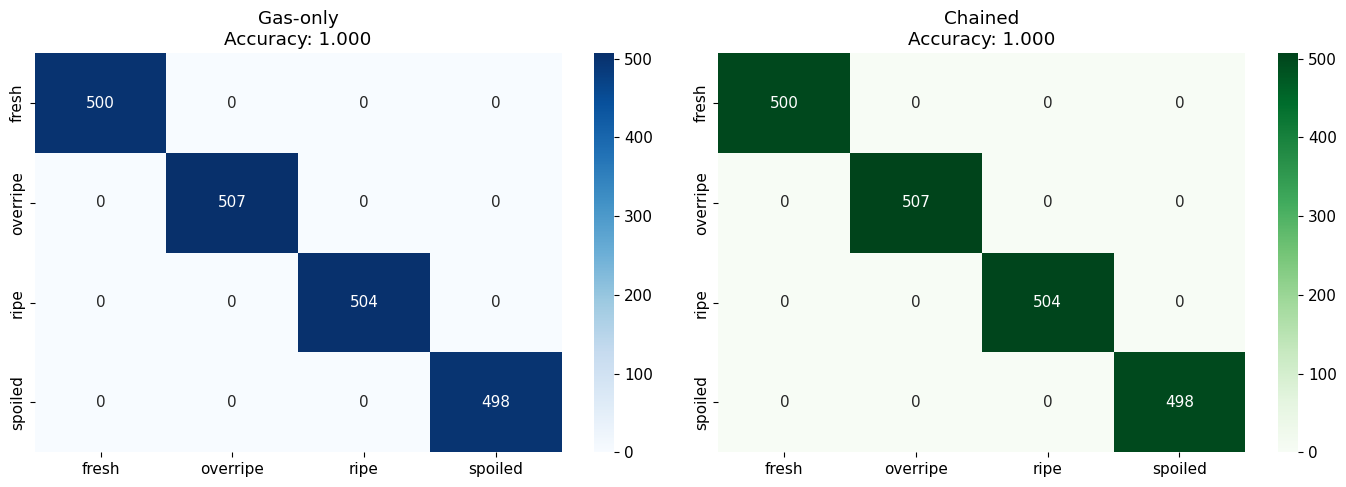

In [42]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_gas = confusion_matrix(y_test, y_pred_gas, labels=all_label_indices)
sns.heatmap(cm_gas, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
axes[0].set_title(f'Gas-only\nAccuracy: {acc_gas:.3f}')

cm_chained = confusion_matrix(y_test, y_pred_chained, labels=all_label_indices)
sns.heatmap(cm_chained, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
axes[1].set_title(f'Chained\nAccuracy: {acc_chained:.3f}')

plt.tight_layout()
plt.show()

## 11. View Tree Rules (sanity check the thresholds)

In [43]:
print('Chained Decision Tree Rules:')
print(export_text(chained_model, feature_names=chained_cols, class_names=list(label_encoder.classes_)))

Chained Decision Tree Rules:
|--- ppm_q75 <= 15114.93
|   |--- ppm_q25 <= 9927.11
|   |   |--- class: fresh
|   |--- ppm_q25 >  9927.11
|   |   |--- class: ripe
|--- ppm_q75 >  15114.93
|   |--- v_mean <= 2.07
|   |   |--- class: overripe
|   |--- v_mean >  2.07
|   |   |--- class: spoiled



## 12. Save Model

In [47]:
# Save the chained model (this is what the fog uses)
joblib.dump(chained_model, os.path.join(OUTPUT_DIR, 'freshcheck_chained_tree.joblib'))
joblib.dump(label_encoder, os.path.join(OUTPUT_DIR, 'label_encoder.joblib'))

config = {
    'feature_columns': chained_cols,
    'gas_feature_columns': gas_only_cols,
    'cv_feature_columns': ['cv_at_least_ripe', 'cv_at_least_overripe', 'cv_at_least_spoiled'],
    'window_size': WINDOW_SIZE,
    'recent_window': RECENT_WINDOW,
    'stage_thresholds': STAGE_THRESHOLDS,
    'stage_order': STAGE_ORDER,
    'stage_to_action': STAGE_TO_ACTION,
    'sensor': SENSOR,
    'sensor_type': 'MQ3',
    'model_depth': BEST_DEPTH,
    'training_samples': len(train_idx),
    'test_accuracy': float(acc_chained),
    'test_f1_macro': float(f1_chained),
    'version': 'v8.1',
}
with open(os.path.join(OUTPUT_DIR, 'model_config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print(f'Saved to {OUTPUT_DIR}/')
print('Files:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f'  {f}')

Saved to ./models_v8/
Files:
  freshcheck_chained_tree.joblib
  label_encoder.joblib
  model_config.json
